# Customer Churn Prediction - Exploratory Data Analysis

## Objective

This notebook performs exploratory data analysis on the Telco Customer Churn dataset.

The goals are:

- Understand dataset structure
- Identify missing values
- Explore feature distributions
- Analyze customer churn patterns
- Generate insights for feature engineering and model building

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv(
    "../data/Telco_Customer_churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Information

- Source: IBM Telco Customer Churn Dataset
- Rows: 7043
- Columns: 21
- Target Variable: Churn

In [3]:
df.shape

(7043, 21)

Observation:

The dataset contains 7043 customer records with 21 columns.
The target variable is Churn.

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Observation:

Most features are categorical.
TotalCharges needs conversion into numerical format.

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.isnull().sum()
(df == " ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Observation:

The dataset contains blank values in TotalCharges.
These values need to be converted and handled before model training.

In [8]:
eda_df = df.copy()
eda_df["TotalCharges"] = pd.to_numeric(
    eda_df["TotalCharges"],
    errors="coerce"
)
eda_df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

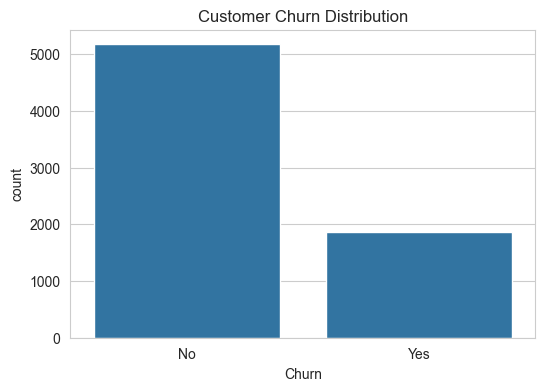

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=eda_df,
    x="Churn"
)

plt.title(
    "Customer Churn Distribution"
)

plt.show()

In [10]:
eda_df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

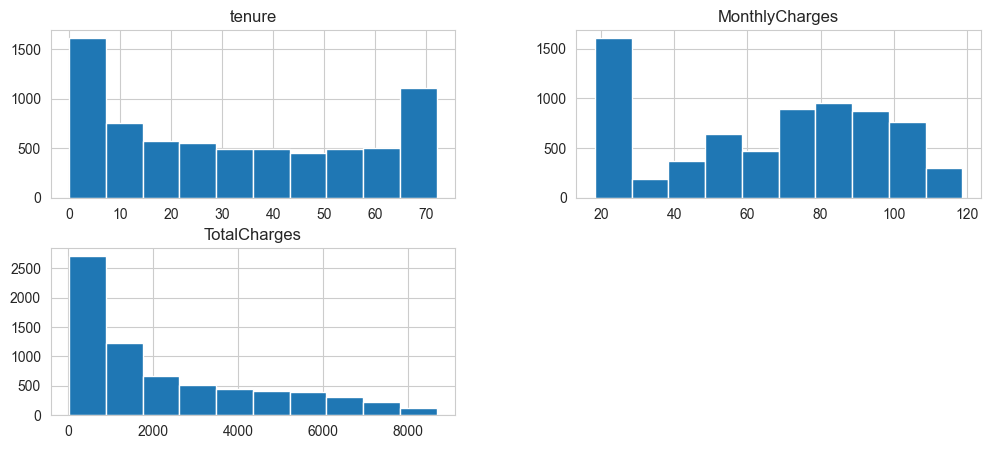

In [11]:
numeric_features=[
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

eda_df[numeric_features].hist(
    figsize=(12,5)
)

plt.show()

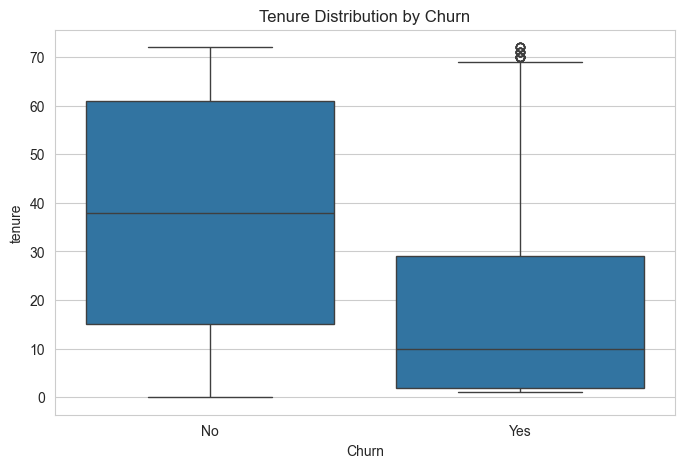

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="Churn",
    y="tenure"
)

plt.title(
    "Tenure Distribution by Churn"
)

plt.show()

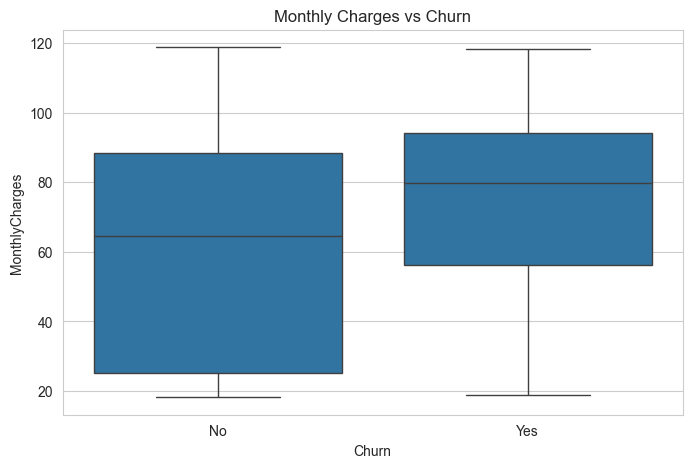

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title(
    "Monthly Charges vs Churn"
)

plt.show()

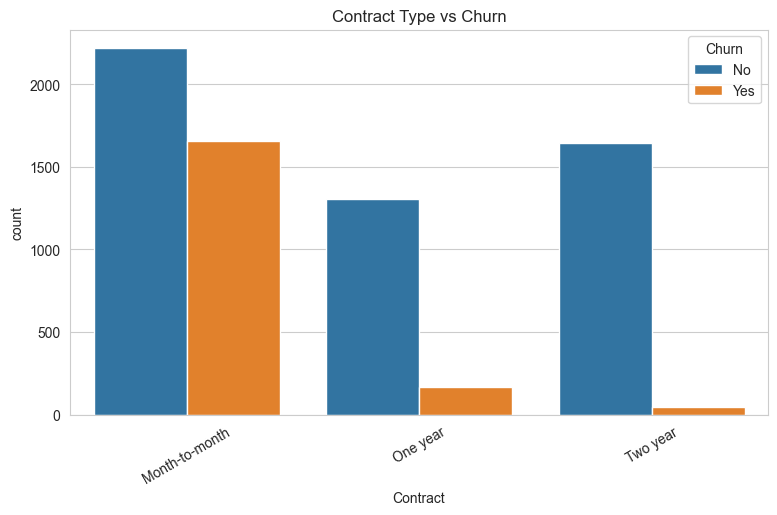

In [14]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=eda_df,
    x="Contract",
    hue="Churn"
)

plt.xticks(
    rotation=30
)

plt.title(
    "Contract Type vs Churn"
)

plt.show()

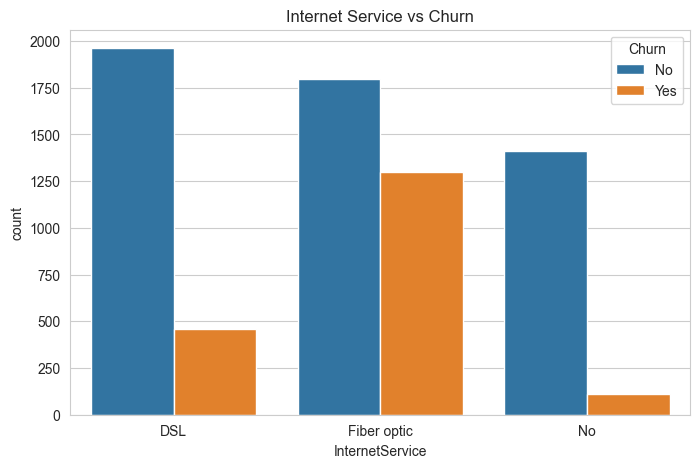

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=eda_df,
    x="InternetService",
    hue="Churn"
)

plt.title(
    "Internet Service vs Churn"
)

plt.show()

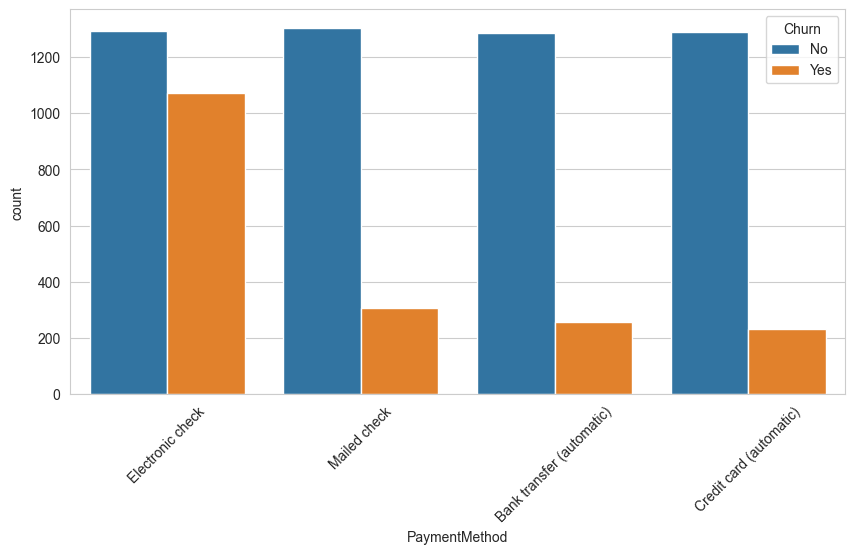

In [16]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=eda_df,
    x="PaymentMethod",
    hue="Churn"
)

plt.xticks(rotation=45)

plt.show()

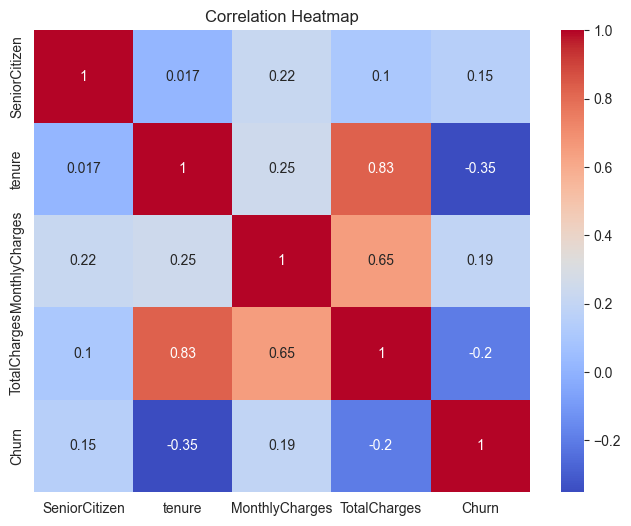

In [17]:
corr_df = eda_df.copy()

corr_df["Churn"] = corr_df["Churn"].map(
    {
        "Yes":1,
        "No":0
    }
)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

# Final EDA Conclusions

## Customer Behavior

- Customers with shorter tenure are significantly more likely to churn.
- Long-term customers exhibit much higher retention.

## Contract Analysis

- Month-to-month contracts experience the highest churn.
- One-year and two-year contracts greatly reduce churn.

## Pricing

- Customers with higher monthly charges have an increased likelihood of leaving.

## Internet Service

- Fiber optic customers show higher churn compared to DSL users.

## Payment Methods

- Electronic check customers churn more frequently than customers using automatic payments.

## Data Quality

- TotalCharges contained blank values and required conversion to numeric.
- CustomerID is an identifier and was removed before model training.

## Modeling Recommendations

- Encode categorical variables.
- Scale numerical variables where appropriate.
- Use tenure, contract type, monthly charges, internet service and payment method as important predictive features.